In [20]:
import pickle as pkl
import pk_plot_library as pplib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import copy
from figrid.data_container import DataContainer

pplib.imports()
COSMO = '/Users/cosinga/overleaf/hi_cosmo_apj/figures/'

In [21]:
ds = pkl.load(open('/Users/cosinga/code/hcolor/fig_md_analysis/12-29_pkdatasort.pkl', 'rb'))
print(ds.getAttrs())

ds.tickArgs(direction = 'in', right = True, top = True, labelsize = 14)
ds.legendArgs(frameon = False, loc = 'upper right', fontsize = 14, slc = (-1, -1))

ds.axisLabelArgs('both', fontsize = 16)
ds.rowLabelArgs(pos = [0.05, 0.05], fontsize = 16, ha = 'left', va = 'bottom')
ds.colLabelArgs(pos = [0.5, 0.95], fontsize = 16, ha = 'center' , va = 'top')
ds.axisArgs(xscale = 'log', yscale = 'log', xlim = [0.04, 10])

ds.setOrder('space', ['real', 'redshift', 'rsd'])

ds.displayAs('space', ['real', 'redshift', 'rsd'], ['Real Space', 'Redshift Space', 'Redshift Space\nDistortions'])
ds.displayAs('snapshot', [99, 67, 50], ['z = 0.0', 'z = 0.5', 'z = 1.0'])
# ds.displayAs('color', ['blue', 'red', 'resolved'], 
#              ['HI $\\times$ Blue Bias', 'HI $\\times$ Red Bias', 'HI $\\times$ Galaxy Bias'])
ds.displayAs('HI_fieldname', ['hisubhalo', 'vn', 'hiptl'], ['Galaxy Centers', 'All Particles', 'Particles in Galaxies'])

ds.setColors('HI_fieldname', ['firebrick', 'saddlebrown', 'sandybrown'], ['vn', 'hiptl', 'hisubhalo'])
ds.setColors('color', ['red', 'blue', 'gray'], ['red', 'blue', 'resolved'])

ds.setXLabel(pplib.wnum())
print(ds.getAttrVals('post_process'))
print(ds.getAttrVals('fieldname'))

['path', 'result_type', 'result_runtime', 'is_auto', 'box', 'simname', 'sim_resolution', 'num_part', 'grid_resolution', 'snapshot', 'redshift', 'axis', 'fieldname', 'is_hydrogen', 'is_atomic', 'is_molecular', 'is_particle', 'is_groupcat', 'is_matter', 'mas', 'space', 'compute_xi', 'compute_slice', 'color', 'gal_species', 'gal_res', 'color_cut', 'ptl_species', 'map', 'model', 'HI_fieldname', 'projection', 'HI_res', 'censat', 'type', 'subtype', 'empty_cells', 'post_process', 'numerator', 'denominator']
['no key found', 'theory_bias', 'obs_bias', 'corr_coef']
['galaxy', 'hiptl_ptl', 'hiptl', 'vn_galaxy', 'hiptl_galaxy', 'galaxy_dust', 'vn_ptl', 'vn', 'ptl', 'hisubhalo_ptl', 'hisubhalo_galaxy', 'hisubhalo', 'galaxy_ptl', 'hisubhalo_galaxy_dust']


In [22]:
def calc_obs_bias(ip):
    ptlip = {'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':ip['path'], 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':ip['snapshot'],
            'space':ip['space']}
    ptl_auto = ds.getMatching(ptlip)
    if len(ptl_auto) > 1:
        print('found too many particles')
        for i in ptl_auto:
            print(i.attrs)
    
    ptl_auto = ptl_auto[0]
    
    auto = ds.getMatching(ip)
    biases = []
    for i in range(len(auto)):
        
        data = [auto[i].data[0], np.sqrt(auto[i].data[1] / ptl_auto.data[1])]
        dc = DataContainer(data)
        dc.update(copy.deepcopy(auto[i].attrs))
        dc.add('post_process','obs_bias')
        dc.add('is_auto', False)
        dc.add('denominator', 'ptl')
        dc.add('_post_time', 'now')

        biases.append(dc)
    return biases

def calc_th_bias(ip):
    ptlip = {'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':ip['path'], 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':ip['snapshot'],
            'space':ip['space']}
    ptl_auto = ds.getMatching(ptlip)
    if len(ptl_auto) > 1:
        print('found too many particles')
        for i in ptl_auto:
            print(i.attrs)
    
    ptl_auto = ptl_auto[0]
    
    cross = ds.getMatching(ip)
    biases = []
    for i in range(len(cross)):
        
        data = [cross[i].data[0], cross[i].data[1] / ptl_auto.data[1]]
        dc = DataContainer(data)
        dc.update(copy.deepcopy(cross[i].attrs))
        dc.add('post_process','theory_bias')
        dc.add('denominator', 'ptl')
        dc.add('_post_time', 'now')
        biases.append(dc)
    return biases
def save_bias(biases):
    SAVE_ATTRS = ['simname', 'snapshot', 'space', 'post_process', 'color', 'model']
    bvals = []
    switch = False
    for bias in biases:
        data = bias.getData()
        names = ['k=%.2f'%data[0][0], 'k=%.2f'%data[0][1], 'avg-high', 'avg-low']
        print(names)
        for calc in names:
            
            if calc == names[0]:
                bval = data[1][0]
            elif calc == names[1]:
                bval = data[1][1]
            elif calc == names[2]:
                bval = np.mean(data[1][0:3])
                if not switch:
                    print(data[0][0], data[0][2], data[0][3])
                    switch = True
            elif calc == names[3]:
                bval = np.mean(data[1][1:4])
                
                
            attrs = [bias.get(attr) for attr in SAVE_ATTRS]
            attrs.append(calc)
            bvals.append([bval, attrs])
    return bvals
        

In [23]:
simnames = ['tng100', 'tng300']
snapshots = [50, 67, 99]
spaces = ['real', 'redshift']
bvals = []
for name in simnames:
    for snap in snapshots:
        for space in spaces:
            

            print("\n", name, snap, space)
            hiip = {'is_auto':True, "HI_fieldname":['vn'],      
              'axis':0, 'grid_resolution':800, 'simname': name,
              'mas':'CICW', 'snapshot':snap, 'space':space,
             'path':'fiducial', 'post_process':'no key found'}
            obs_biases = calc_obs_bias(hiip)
            print('hi biases:', len(obs_biases))
            ds.extend(obs_biases)
            bvals.extend(save_bias(obs_biases))
            galip = {'gal_res':'diemer',
                      'gal_species':'stmass', 'sim_resolution':'high', 
                     'axis':0, 'grid_resolution':800,
                      'censat':['no key found', 'both'], 'mas':'CICW', 
                     'color': ['blue', 'red', 'resolved'], 'fieldname':'galaxy',
                     'path':'fiducial', 'simname':name, 'space':space,
                    'snapshot':snap, 'post_process':'no key found'}
            obs_biases = calc_obs_bias(galip)
            print('galaxy biases:', len(obs_biases))
            bvals.extend(save_bias(obs_biases))
            ds.extend(obs_biases)


 tng100 50 real
hi biases: 1
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
0.11866188299595938 0.28597202486091156 0.3711547701985702
galaxy biases: 3
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
0.11866188299595938 0.28597202486091156 0.3711547701985702
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']

 tng100 50 redshift
hi biases: 1
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
0.11866188299595938 0.28597202486091156 0.3711547701985702
galaxy biases: 3
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
0.11866188299595938 0.28597202486091156 0.3711547701985702
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']

 tng100 67 real
hi biases: 1
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
0.11866188299595938 0.28597202486091156 0.3711547701985702
galaxy biases: 3
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
0.11866188299595938 0.28597202486091156 0.3711547701985702
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.12', 'k=0.2

In [24]:
print('to be used for table')
for b in bvals:
    if 'tng300' in b[1] and 'real' in b[1] and ('avg-high' in b[1]):
        print(b[1][1], b[1][4], b[1][-1], b[0])

to be used for table
50 no key found avg-high 1.2798532232556898
50 blue avg-high 1.7756160508085268
50 red avg-high 2.6800002341261817
50 resolved avg-high 2.0679164957840936
67 no key found avg-high 0.9932437178389568
67 blue avg-high 1.3051201923442584
67 red avg-high 2.1464896835712204
67 resolved avg-high 1.7256389763353017
99 no key found avg-high 0.7478271567061437
99 blue avg-high 0.9201993760070185
99 red avg-high 1.6836183044071564
99 resolved avg-high 1.4734168804416061


In [25]:
print('used for ratios')
for b in bvals:
    if 'tng300' in b[1] and 'real' in b[1] and ('k=0.07' in b[1]):
        print(b[1][1], b[1][4], b[1][-1], b[0])

used for ratios
50 no key found k=0.07 1.292068184052896
50 blue k=0.07 1.7396967077251075
50 red k=0.07 2.613338613955335
50 resolved k=0.07 2.044481908581083
67 no key found k=0.07 1.006335454892207
67 blue k=0.07 1.305874537802232
67 red k=0.07 2.101129534099574
67 resolved k=0.07 1.7110370337720227
99 no key found k=0.07 0.7664835743116538
99 blue k=0.07 0.9346407176458006
99 red k=0.07 1.6625237212281365
99 resolved k=0.07 1.4682604650366469


In [35]:
simnames = ['tng100', 'tng300']
snapshots = [50, 67, 99]
spaces = ['real', 'redshift']

for name in simnames:
    for snap in snapshots:
        for space in spaces:

            print("\n", name, snap, space)
            hiip = {'is_auto':False, "fieldname":['vn_ptl', 'hiptl_ptl'],      
              'axis':0, 'grid_resolution':800, 'simname': name,
              'mas':'CICW', 'snapshot':snap, 'space':space,
             'path':'fiducial', 'post_process':'no key found',
                   'ptl_species':['no key found', 'ptl']}
            th_biases = calc_th_bias(hiip)
            print('hi biases:', len(th_biases))
            ds.extend(th_biases)
            bvals.extend(save_bias(th_biases))
            galip = {'gal_res':'diemer',
                  'gal_species':'stmass', 'sim_resolution':'high', 
                 'axis':0, 'grid_resolution':800,
                  'censat':['no key found', 'both'], 'mas':'CICW', 
                 'color': ['blue', 'red', 'resolved'], 'fieldname':'galaxy_ptl',
                 'path':'fiducial', 'simname':name, 'space':space,
                'snapshot':snap, 'post_process':'no key found', 'ptl_species':['ptl', 'no key found']}
            th_biases = calc_th_bias(galip)
            print('galaxy biases:', len(th_biases))
            bvals.extend(save_bias(th_biases))

            ds.extend(th_biases)


 tng100 50 real
hi biases: 5
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
0.11866188299595938 0.28597202486091156 0.3711547701985702
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
galaxy biases: 3
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
0.11866188299595938 0.28597202486091156 0.3711547701985702
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']

 tng100 50 redshift
hi biases: 5
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
0.11866188299595938 0.28597202486091156 0.3711547701985702
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
galaxy biases: 3
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
0.11866188299595938 0.28597202486091156 0.3711547701985702
['k=0.12', 'k=0.20', 'avg-high', 'avg-low']
['k=0.

In [26]:
# printing out the bias values

for b in bvals:
    if 'tng300' in b[1] and 'real' in b[1] and 'resolved' in b[1]:
        print(b)

[2.085672443425789, ['tng300', 50, 'real', 'obs_bias', 'resolved', 'no key found', 'k=0.04']]
[2.044481908581083, ['tng300', 50, 'real', 'obs_bias', 'resolved', 'no key found', 'k=0.07']]
[2.0679164957840936, ['tng300', 50, 'real', 'obs_bias', 'resolved', 'no key found', 'avg-high']]
[2.0902601580199054, ['tng300', 50, 'real', 'obs_bias', 'resolved', 'no key found', 'avg-low']]
[1.7356951522188733, ['tng300', 67, 'real', 'obs_bias', 'resolved', 'no key found', 'k=0.04']]
[1.7110370337720227, ['tng300', 67, 'real', 'obs_bias', 'resolved', 'no key found', 'k=0.07']]
[1.7256389763353017, ['tng300', 67, 'real', 'obs_bias', 'resolved', 'no key found', 'avg-high']]
[1.7416008087107262, ['tng300', 67, 'real', 'obs_bias', 'resolved', 'no key found', 'avg-low']]
[1.477574909127928, ['tng300', 99, 'real', 'obs_bias', 'resolved', 'no key found', 'k=0.04']]
[1.4682604650366469, ['tng300', 99, 'real', 'obs_bias', 'resolved', 'no key found', 'k=0.07']]
[1.4734168804416061, ['tng300', 99, 'real', 'ob

In [27]:
ip = {'is_auto':False, 
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'], 'gal_res':'diemer',
      'gal_species':'stmass','ptl_species':['ptl', 'no key found'],
      'censat':['no key found', 'both'], 'mas':'CICW', 'color': ['resolved'],
      'post_process':['obs_bias'], 'snapshot':[50], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
galbias = ds.getMatching(ip)[0]
data = galbias.getData()
pkl.dump(data, open('../gal_bias_demo_50.pkl', 'wb'), pkl.HIGHEST_PROTOCOL)

ip = {'is_auto':False, 
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'HI_fieldname':['vn'],'ptl_species':['ptl', 'no key found'],
          'censat':['no key found', 'both'], 'mas':'CICW',
          'post_process':['obs_bias'], 'snapshot':[50], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', 'numerator':'no key found'}
hibias = ds.getMatching(ip)
print(len(hibias))
data = hibias[0].getData()
pkl.dump(data, open('../hi_bias_demo_50.pkl', 'wb'), pkl.HIGHEST_PROTOCOL)


1


The row values for post_process: ['obs_bias', 'theory_bias']
The column values for snapshot: [99, 67, 50]


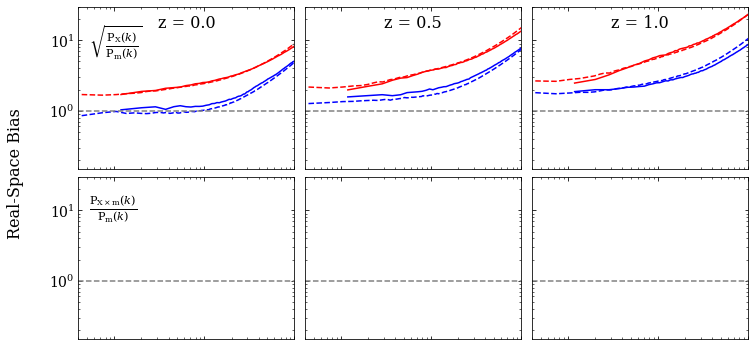

In [28]:
combine_rr = True
ip = {'is_auto':False, 
      'axis':0, 'grid_resolution':800, 'simname': ['tng100', 'tng300'], 'gal_res':'diemer',
      'gal_species':'stmass','ptl_species':['ptl', 'no key found'],
      'censat':['no key found', 'both'], 'mas':'CICW', 'color': ['red', 'blue'],
      'post_process':['obs_bias', 'theory_bias'], 'snapshot':[99, 67, 50], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
gspec = {'wspace':0.05, 'hspace':0.05, 'xborder':[0.33, 0]}
fn = 'k'
name1 = '\\mathrm{X}'
name2 = '\\mathrm{m}'
obsbias = '$\\sqrt{\\frac{\\mathrm{P}_{%s} (%s)}{\\mathrm{P}_{%s} (%s)}}$'%(name1, fn, name2, fn)
thbias = '$\\frac{\\mathrm{P}_{%s \\times %s} (%s)}{\\mathrm{P}_{%s} (%s)}$'%(name1, name2, fn, name2, fn)

bfg = ds.figrid("color", 'post_process', 'snapshot', ip)
bfg.setPanelsize(3, 2.25)

bfg.rowLabels([obsbias, thbias], pos = (0.05, 0.9))
bfg.rowLabelArgs(va = 'top')
bfg.gspecArgs(yborder = [0.05, 0.25], **gspec)
bfg.plotArgs({}, label = '')
bfg.plotArgs({'simname':'tng300'}, linestyle = 'dashed')
bfg.setDefaultTicksParams()
if combine_rr:
    bfg.tickArgs(labelbottom = False)
    bfg.setXLabel('')
else:
    bfg.setXLabel(pplib.wnum())

bfg.axisArgs(ylim = (.15, 30))
bfg.setYLabel('Real-Space Bias')
bfg.plotOnes()
bfg.legendArgs(rm_legend = True)
bfg.plot()

The row values for post_process: ['obs_bias']
The column values for snapshot: [99, 67, 50]


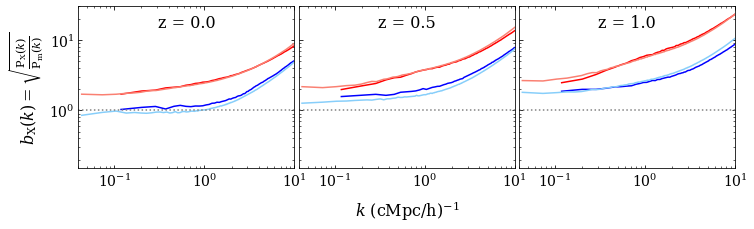

In [32]:
combine_rr = False
ip = {'is_auto':False, 
      'axis':0, 'grid_resolution':800, 'simname': ['tng100', 'tng300'], 'gal_res':'diemer',
      'gal_species':'stmass','ptl_species':['ptl', 'no key found'],
      'censat':['no key found', 'both'], 'mas':'CICW', 'color': ['red', 'blue'],
      'post_process':['obs_bias'], 'snapshot':[99, 67, 50], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
gspec = {'wspace':0.02, 'hspace':0.05, 'xborder':[0.33, 0]}
fn = 'k'
name1 = '\\mathrm{X}'
name2 = '\\mathrm{m}'
obsbias = '$b_{%s} (k) = \\sqrt{\\frac{\\mathrm{P}_{%s} (%s)}{\\mathrm{P}_{%s} (%s)}}$'%(name1, name1, fn, name2, fn)
thbias = '$\\frac{\\mathrm{P}_{%s \\times %s} (%s)}{\\mathrm{P}_{%s} (%s)}$'%(name1, name2, fn, name2, fn)

bfg = ds.figrid("color", 'post_process', 'snapshot', ip)
bfg.setPanelsize(3, 2.25)

bfg.rowLabels([''], pos = (0.05, 0.9))
bfg.rowLabelArgs(va = 'top')
bfg.gspecArgs(yborder = [0.05, 0.33], **gspec)
bfg.plotArgs({}, label = '__nolegend__')

bfg.plotArgs({'simname':'tng300', 'color':'blue'}, label = 'Blue Gal.', slc = (slice(None), 1))
bfg.plotArgs({'color':'red', 'simname':'tng300'}, label = 'Red Gal.', slc = (slice(None), 1))
bfg.plotArgs({'simname':'tng300', 'color':'blue'}, color = 'lightskyblue')
bfg.plotArgs({'color':'red', 'simname':'tng300'}, color = 'salmon')

bfg.setDefaultTicksParams()

if combine_rr:
    bfg.tickArgs(labelbottom = False)
    bfg.setXLabel('')
else:
    bfg.setXLabel(pplib.wnum())

bfg.axisArgs(ylim = (.15, 30))
bfg.setYLabel(obsbias)
bfg.legendArgs(rm_legend = True)
bfg.plotOnes(linestyle = ':')
bfg.plot()

The row values for post_process: ['obs_bias']
The column values for snapshot: [99, 67, 50]


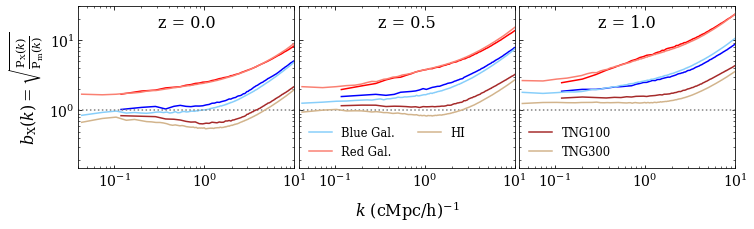

<Figure size 810x270 with 0 Axes>

In [33]:
def add_hi_real(bfg):
    ip = {'is_auto':False, 
          'axis':0, 'grid_resolution':800, 'simname': ['tng100', 'tng300'],
          'HI_fieldname':['vn'],'ptl_species':['ptl', 'no key found'],
          'censat':['no key found', 'both'], 'mas':'CICW',
          'post_process':['obs_bias'], 'snapshot':[99, 67, 50], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', 'numerator':'no key found'}
    hifg = ds.figrid("simname", 'post_process', 'snapshot', ip)
    hifg.rowLabels(["", ""])
    hifg.colLabels([""]*4)
    hifg.plotArgs({'simname':'tng100'}, label = '__nolegend__', color = 'brown')
    hifg.plotArgs({'simname':'tng300'}, label = '__nolegned__', color = 'tan')
    hifg.plotArgs({'simname':'tng100'}, color = 'brown', label = 'TNG100', slc = (slice(None), 2))
    hifg.plotArgs({'simname':'tng300'}, color = 'tan', label = 'TNG300', slc = (slice(None), 2))
    hifg.plotArgs({'simname':'tng300'}, label = 'HI', slc = (slice(None), 1))
#     hifg.autoFill(alpha = 0.6)
    hifg.plot(axes = bfg.axes)
    real_bfg = bfg

    return

add_hi_real(bfg)
bfg.axes[0, 2].legend(loc = 'lower left', frameon = False, fontsize = 11.5)
bfg.axes[0, 1].legend(loc = 'lower left', frameon = False, fontsize = 11.5, ncol = 2)
if not combine_rr:
    bfg.save(COSMO + 'bias_tng100-300_real.pdf', dpi = 200)
bfg.fig

The row values for : ['no key found']
The column values for snapshot: [99, 67, 50]
The row values for : ['no key found']
The column values for snapshot: [99, 67, 50]


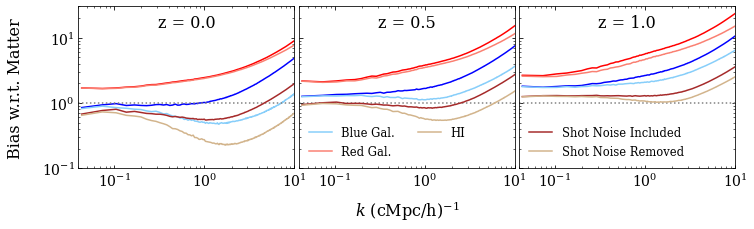

<Figure size 810x270 with 0 Axes>

In [36]:
# making theory vs obs bias comparison
ip = {'is_auto':False, 
      'axis':0, 'grid_resolution':800, 'simname': ['tng300'], 'gal_res':'diemer',
      'gal_species':'stmass','ptl_species':['ptl', 'no key found'],
      'censat':['no key found', 'both'], 'mas':'CICW', 'color': ['red', 'blue'],
      'post_process':['obs_bias', 'theory_bias'], 'snapshot':[99, 67, 50], 'space':'real',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
def add_hi_real(bfg):
    ip = {'is_auto':False, 
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'HI_fieldname':['vn'],'ptl_species':['ptl', 'no key found'],
          'censat':['no key found', 'both'], 'mas':'CICW',
          'post_process':['obs_bias', 'theory_bias'], 'snapshot':[99, 67, 50], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', 'numerator':'no key found'}
    hifg = ds.figrid("post_process", '', 'snapshot', ip)
    hifg.rowLabels(["", ""])
    hifg.colLabels([""]*4)
    hifg.plotArgs({'post_process':'obs_bias'}, color = 'brown', label = '__nolegend__')
    hifg.plotArgs({'post_process':'theory_bias'}, color = 'tan', label = '__nolegend__')

    hifg.plotArgs({'post_process':'obs_bias'}, color = 'brown', label = 'Shot Noise Included', slc = (slice(None), 2))
    hifg.plotArgs({'post_process':'theory_bias'}, color = 'tan', label = 'Shot Noise Removed', slc = (slice(None), 2))
    hifg.plotArgs({'post_process':'theory_bias'}, label = 'HI', slc = (slice(None), 1))
#     hifg.autoFill(alpha = 0.6)
    hifg.plot(axes = bfg.axes)
    real_bfg = bfg
    return

gspec = {'wspace':0.02, 'hspace':0.05, 'xborder':[0.33, 0]}
fn = 'k'
name1 = '\\mathrm{X}'
name2 = '\\mathrm{m}'
obsbias = '$b_{%s} (k) = \\sqrt{\\frac{\\mathrm{P}_{%s} (%s)}{\\mathrm{P}_{%s} (%s)}}$'%(name1, name1, fn, name2, fn)
thbias = '$\\frac{\\mathrm{P}_{%s \\times %s} (%s)}{\\mathrm{P}_{%s} (%s)}$'%(name1, name2, fn, name2, fn)

bfg = ds.figrid("color", '', 'snapshot', ip)
bfg.setPanelsize(3, 2.25)

bfg.rowLabels([''], pos = (0.05, 0.9))
bfg.rowLabelArgs(va = 'top')
bfg.gspecArgs(yborder = [0.05, 0.33], **gspec)
bfg.plotArgs({}, label = '__nolegend__')

bfg.plotArgs({'post_process':'theory_bias', 'color':'blue'}, label = 'Blue Gal.', slc = (slice(None), 1))
bfg.plotArgs({'color':'red', 'post_process':'theory_bias'}, label = 'Red Gal.', slc = (slice(None), 1))
bfg.plotArgs({'post_process':'theory_bias', 'color':'blue'}, color = 'lightskyblue')
bfg.plotArgs({'color':'red', 'post_process':'theory_bias'}, color = 'salmon')

bfg.setDefaultTicksParams()

if combine_rr:
    bfg.tickArgs(labelbottom = False)
    bfg.setXLabel('')
else:
    bfg.setXLabel(pplib.wnum())

bfg.axisArgs(ylim = (.1, 30))
bfg.setYLabel('Bias w.r.t. Matter')
bfg.legendArgs(rm_legend = True)
bfg.plotOnes(linestyle = ':')
bfg.plot()
add_hi_real(bfg)
bfg.axes[0, 2].legend(loc = 'lower left', frameon = False, fontsize = 11.5)
bfg.axes[0, 1].legend(loc = 'lower left', frameon = False, fontsize = 11.5, ncol = 2)
if not combine_rr:
    bfg.save(COSMO + 'bias_shot_noise.pdf', dpi = 200)

The row values for post_process: ['obs_bias', 'theory_bias']
The column values for snapshot: [99, 67, 50]


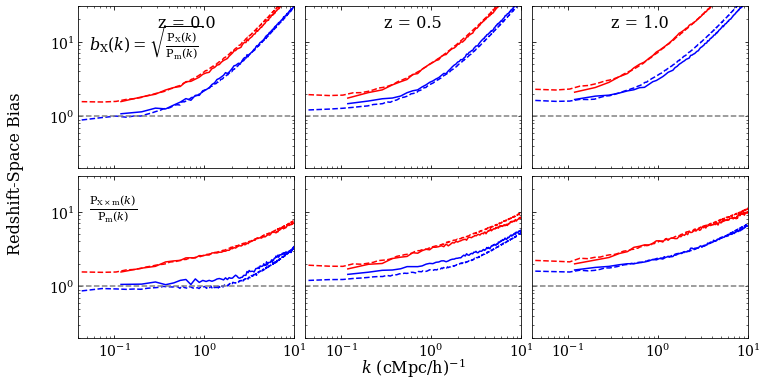

In [75]:

ip = {'is_auto':False, 
      'axis':0, 'grid_resolution':800, 'simname': ['tng100', 'tng300'], 'gal_res':'diemer',
      'gal_species':'stmass','ptl_species':['ptl', 'no key found'],
      'censat':['no key found', 'both'], 'mas':'CICW', 'color': ['red', 'blue'],
      'post_process':['obs_bias', 'theory_bias'], 'snapshot':[99, 67, 50], 'space':'redshift',
     'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}


bfg = ds.figrid("color", 'post_process', 'snapshot', ip)
bfg.setPanelsize(3, 2.25)
bfg.rowLabels([obsbias, thbias], pos = (0.05, 0.9))
bfg.rowLabelArgs(va = 'top')
if combine_rr:
    bfg.colLabels(['']*4)
bfg.gspecArgs(yborder = [0.05, 0.25], **gspec)
bfg.plotArgs({}, label = '')
bfg.plotArgs({'simname':'tng300'}, linestyle = 'dashed')
bfg.setDefaultTicksParams()
bfg.axisArgs(ylim = (.2, 30))
bfg.setYLabel('Redshift-Space Bias')
bfg.setXLabel(pplib.wnum())
bfg.plotOnes()

bfg.legendArgs(rm_legend = True)
bfg.plot()

The row values for post_process: ['obs_bias', 'theory_bias']
The column values for snapshot: [99, 67, 50]


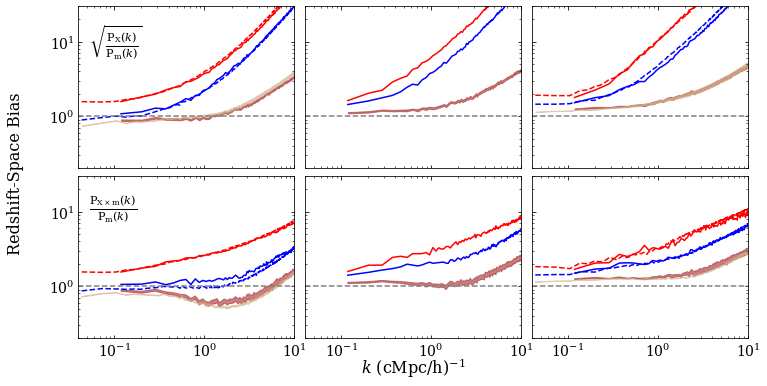

<Figure size 810x540 with 0 Axes>

In [61]:
def add_hi_red(bfg):
    ip = {'is_auto':False, 
          'axis':0, 'grid_resolution':800, 'simname': ['tng100', 'tng300'],
          'HI_fieldname':['vn', 'hiptl'],'ptl_species':['ptl', 'no key found'],
          'censat':['no key found', 'both'], 'mas':'CICW',
          'post_process':['obs_bias', 'theory_bias'], 'snapshot':[99, 67, 50], 'space':'redshift',
         'path':'fiducial', 'denominator':'ptl', 'numerator':'no key found'}
    hifg = ds.figrid("simname", 'post_process', 'snapshot', ip)
    hifg.rowLabels(["", ""])
    hifg.colLabels([""]*4)
    hifg.plotArgs({'simname':'tng100'}, color = 'brown', label = '')
    hifg.plotArgs({'simname':'tng300'}, color = 'tan', label = '')
    hifg.autoFill(alpha = 0.6)
    hifg.legendArgs(rm_legend = True)
    hifg.plot(axes = bfg.axes)
    if not combine_rr:
        bfg.save(COSMO + 'bias_tng100-300_real_hbr_placeholder.png')
    return
add_hi_red(bfg)
bfg.fig

The row values for post_process: ['obs_bias', 'theory_bias']
The column values for snapshot: [99, 67, 50]
The row values for post_process: ['obs_bias', 'theory_bias']
The column values for snapshot: [99, 67, 50]


/var/folders/79/98r4p1nd3v19cl5z3dbndg_c0000gn/T/ipykernel_97503/1827769122.py:8: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


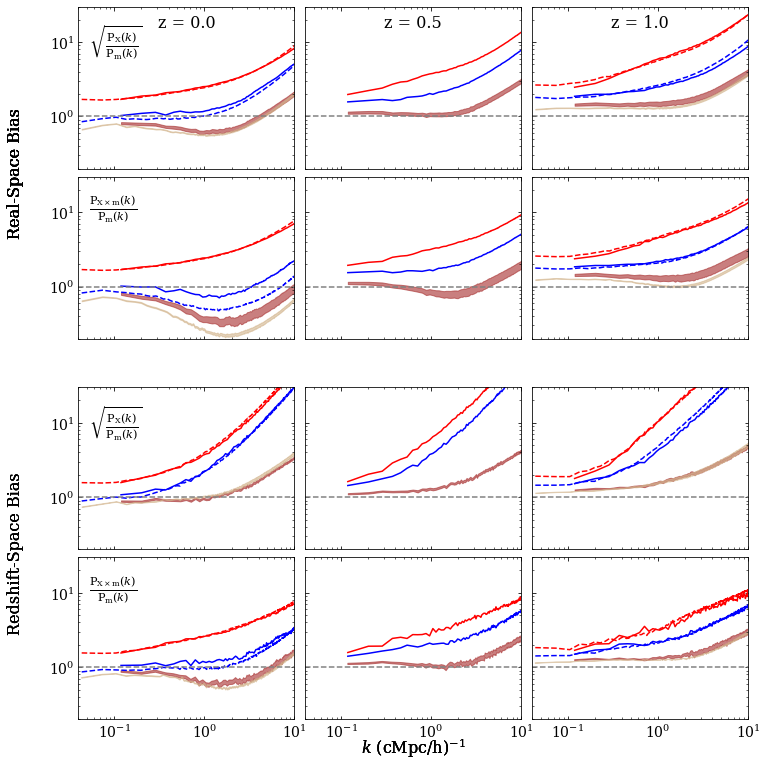

<Figure size 810x540 with 0 Axes>

<Figure size 810x540 with 0 Axes>

In [63]:
if combine_rr:
    figarr = np.empty((2, 1), dtype = object)
    figarr[0, 0] = real_bfg
    figarr[1, 0] = bfg
    fig = bfg.combine(figarr)
    add_hi_real(real_bfg)
    add_hi_red(bfg)
    fig.show()
    fig.savefig(COSMO + "bias_tng100-300_hbr_placeholder.png", bbox_inches = 'tight')